<a href="https://colab.research.google.com/github/ryan-merser/ST554-BigData/blob/main/ST554_HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ST554: Analysis of Big Data Homework 5

Ryan Mersereau

## Part 1: Concepts

We discussed the “Five V’s of Big Data”. Give an example of a place where you’ve encountered big
data or a topic you are interested in where big data would arise.

For this, I'll use the example of data collection in the NBA

### 1. Five V's of Big Data
**Volume**: The NBA has a rich history, being formed in 1946. Since 1968, NBA teams are scheduled to play 83 games during the regular season (October to April), with additional playoff games after the season. Each team and individual player on the team has numerous data that can be tracked, which quickly adds up to a huge amount!

**Variety**: A quick google search says NBA data is extracted from optical (live camera) tracking of players powered by machine learning algorithms, and several official statisticians in each game. These statisticians may have their own methods for recording data different from each other (software differences, variable names, conventions) and different from the optical tracking, leading to a large variety of data.

**Value**: Some data may be much more valuable than others in certain contexts. For example, the league and analysts need to extract accurate information about which players are performing the best to give out the MVP award.

**Velocity**: Several NBA games take place almost every night during the regular season, typically between 5 to 10. This means large amounts of new data is constantly being recorded and stored somewhere daily.

**Veracity**: With the amount of data recorded, data entry errors aren't impossible for statisticians and algorithms. Other elements of basketball add to uncertainty of data, such as subjectivity of refs and injuries of players.

### 2. CRUD Exmaples

Read about the database we’ll use below (part IV) Give an example for each letter in the CRUD acronym in the context of this database.

**Create**: Create a new player or team record from the current year

**Read**: Query a stat like top 10 players with most home runs from a particular year

**Update**: Correct a particular players stat in the event of data entry error, such as on base percentage.

**Delete**: Remove a duplicate entry of a player if, for example, it was converted incorrectly from Access.



### 3. What is the purpose of the HAVING clause when writing SQL code?

From the [SQLite tutorial page ](https://www.sqlitetutorial.net/sqlite-having/), The HAVING clause is optional for the SELECT statement, and it specifies a search condition for a group. HAVING usually follows up a GROUP BY clause when using the SELECT statement to query data.

## Part 2: Simulation of a Sampling Distribution



### 4. Investigation of $\hat{p}$

We looked at using simulation to investigate the sampling distribution of $\hat{p}$ in the notes. We’ll now look at the sampling distribution of the sample slope from an SLR model using simulation. We assume a standard model for SLR, and can generate data for this model by assuming values for slope coefficients and n using the following code:

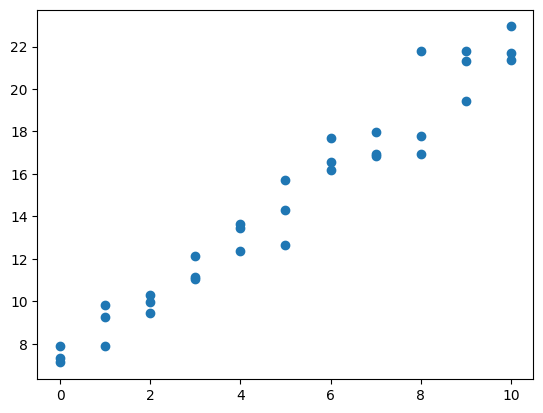

In [ ]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = 33
#create the 'responses' modeled from the line plus a random deviation
y = beta_0 + beta_1*x + rng.standard_normal(n)
#visualize the data
plt.scatter(x = x, y = y)
plt.show()


Now, we can use sklearn to obtain the estimate for the slope and save the value.

In [ ]:
from sklearn import linear_model

#Reshape X to be 2d
X = x.reshape(-1,1)

model = linear_model.LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_

print(slope)
print(intercept)

1.4745056382493755
7.259043801350283


### Simulation
Now, lets repeat this process 5000 times, and do the following:

* Generate the y values using the code with rng.standard_normal()
* Find the ‘best’ slope via sklearn
* Save that slope in some object


In [ ]:
slopes = []

for i in range(5000):
  y_sim = beta_0 + beta_1*x + rng.standard_normal(n)
  model.fit(X, y_sim)
  slopes.append(model.coef_[0])

#Convert slopes to numpy array
slopes = np.array(slopes)

### Histogram of slopes
We can use the many values of the sample slope as an approximation to the sampling distribution of the sample slope! Let's Create a histogram of the sample slope values.

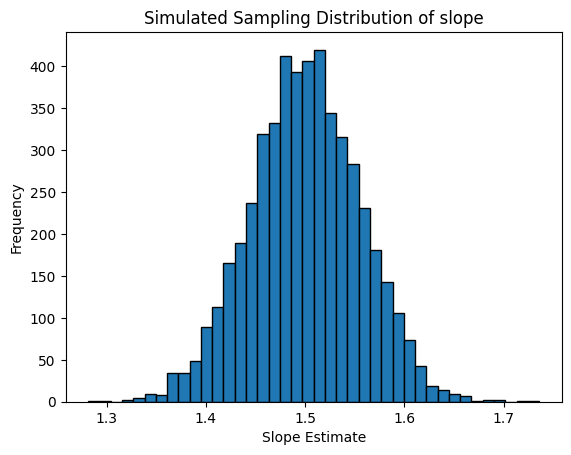

In [ ]:
plt.hist(slopes, bins = 40, edgecolor = 'black')
plt.xlabel("Slope Estimate")
plt.ylabel("Frequency")
plt.title("Simulated Sampling Distribution of slope")
plt.show()

We can use the results of this simulation and histogram to do many things, such as approximate probabilities. For example, let's approximate the probability of observing a sample slope larger than 1.65 by looking at the proportion of simulated values larger than 1.65.

In [ ]:
print((slopes > 1.65).mean())

0.0038


### Interpretation

This result of 0.0038 means that only 0.38% of simulations returned an estimated slope of 1.65 or higher. Looking at the histogram, this makes sense as these values would fall in the extreme of the right tail. What we did in this sampling distribution simulation is bootstrapping, where we approximate p-values just using the data without needing distributions.

This could be set up as a hypothesis test. If we observed real data where the slope was observed to be 1.65, we could test $H_0: \beta_1 = 1.5$ vs $H_A: \beta_1 > 1.5$. Here, 0.0038 functions as a p-value, and we could reject $H_0$.

## Part 3: Big Data Examples & Rare Events

### 5. Data Issue Example

Pick an example in the [article](https://international-review.icrc.org/articles/biases-machine-learning-big-data-analytics-ihl-implications-913) and briefly outline the issue around the data used to fit the model.


Selection bias with security cameras: This article gives one example where a model to operate security cameras is trained only on night-time data, then introduced to daytime data. Selection bias has been introduced to this data by only selecting night time conditions to train on, and the model may not perform as well during the day.

We might augment the data in this example by training the model in approximately even splits of night-time and daytime conditions, or if the model is trained solely in the night-time, it should only be tested during the night-time.

### 6. Big Data Usage in Earth Sciences

**Outlook**: The outlook section in this [article](https://www.science.org/doi/10.1126/science.adh9607) mentions "big data’s volume, variety, and veracity can make its use intractable", referencing 3 of the 5 V's of data. This section talks about a new way of recording Earth science data that is "synthesized, structured, and organized presentations of scientific data, findings, and research outcomes in a format that is accessible, informative, and useful". The goal is to turn this big data into actionable insights, but they mention the cons of working with it, including time, size of data, and requirements. However, "These challenges are outweighed by the promise that big data bring for a deeper, more comprehensive understanding of our Earth."



I think many of the biases from the previous article could come up and potentially cause issues for Earth science data. Weather changes constantly and conditions vary rapidly, so in order to get a comprehensive model a large variety of data must be covered. Selection bias of only recording weather when convenient should be avoided. Reporting bias could also come up with news outlets and journalists, for example exaggerating forecasted snowfall to get more views. Since much of this data collection is done by computers, automation bias could also impact results, as humans may tend to favor these results over other, manual methods.

### 7. Rare Event Brainstorming

Some other scenarios similar to 'megabolts' where extreme rare events occur in a sort of log-normal distribution are:

* Other natural disasters: Wildfires, Floods, Volcanic eruptions

* Spread of pandemic
  * Happen rarely, most people only affect a few individuals, but some people spread illness to hundreds (Rudy Gobert)

* Stock market crashes
  * Most days, the stock market will fluctuate by very little amounts, but some days markets will plummet immensely

For all these examples, using a normal distribution assumption would greatly underestimate the tail risk, as these rare event can have devastating impacts. Therefore, the event is not an outlier to be ignored, we should try to understand the event distribution and highlight the impact and frequency of these events.

## Part 4: Querying a database

We'll be working with the Lahman.db database containing information on the MLB

### 8. Connect to the database and view all tables

In [2]:
import sqlite3
import pandas as pd

con = sqlite3.connect("lahman_1871-2022.sqlite")

# Query to return all tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", con)
tables

,name
0,AllstarFull
1,Appearances
2,AwardsManagers
3,AwardsPlayers
4,AwardsShareManagers
5,AwardsSharePlayers
6,Batting
7,BattingPost
8,CollegePlaying
9,Fielding


### 9. Query for 2015 teams

Now, lets write an SQL query using pd.read_sql() that returns all the teams that played in the year 2015 with all of the corresponding columns from the Teams table.

In [3]:
team_query = """
SELECT *
FROM Teams
WHERE yearID = 2015
"""

teams_2015 = pd.read_sql(team_query, con)
teams_2015

,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,2015,AL,BAL,BAL,E,3,162,78,81,81,...,134,0.987,Baltimore Orioles,Oriole Park at Camden Yards,2281202,103,104,BAL,BAL,BAL
1,2015,AL,BOS,BOS,E,5,162,81,78,84,...,148,0.984,Boston Red Sox,Fenway Park II,2880694,104,107,BOS,BOS,BOS
2,2015,AL,CHA,CHW,C,4,162,81,76,86,...,159,0.983,Chicago White Sox,U.S. Cellular Field,1755810,92,93,CHW,CHA,CHA
3,2015,AL,CLE,CLE,C,3,161,80,81,80,...,136,0.987,Cleveland Indians,Progressive Field,1388905,106,106,CLE,CLE,CLE
4,2015,AL,DET,DET,C,5,161,81,74,87,...,165,0.986,Detroit Tigers,Comerica Park,2726048,97,98,DET,DET,DET
5,2015,AL,HOU,HOU,W,2,162,81,86,76,...,131,0.986,Houston Astros,Minute Maid Park,2153585,97,99,HOU,HOU,HOU
6,2015,AL,KCA,KCR,C,1,162,81,95,67,...,138,0.985,Kansas City Royals,Kauffman Stadium,2708549,104,103,KCR,KCA,KCA
7,2015,AL,LAA,ANA,W,3,162,81,85,77,...,108,0.984,Los Angeles Angels of Anaheim,Angel Stadium of Anaheim,3012765,94,95,LAA,ANA,ANA
8,2015,AL,MIN,MIN,C,2,162,81,83,79,...,150,0.986,Minnesota Twins,Target Field,2220054,103,104,MIN,MIN,MIN
9,2015,AL,NYA,NYY,E,2,162,81,87,75,...,135,0.985,New York Yankees,Yankee Stadium III,3193795,99,101,NYY,NYA,NYA


### 10. Query for Hall of fame players

Now, let's write an SQL query using pd.read_sql() that returns all of the players in the hall of fame, the year they were voted into the hall of fame, and their category.

In [4]:
hof_query = """
SELECT playerID, yearid, category
FROM HallOfFame
WHERE inducted = 'Y'
"""

hof_players = pd.read_sql(hof_query, con)
hof_players

,playerID,yearid,category
0,aaronha01,1982,Player
1,alexape01,1938,Player
2,alomaro01,2011,Player
3,alstowa01,1983,Manager
4,andersp01,2000,Manager
...,...,...,...
335,yastrca01,1989,Player
336,yawketo99,1980,Pioneer/Executive
337,youngcy01,1937,Player
338,youngro01,1972,Player


### 11. Query for Pirates Managers

Next, lets write an SQL query using pd.read_sql() that return all unique managers of the Pittsburgh Pirates (teamID of PIT) and only that information from the Managers table.

In [5]:
pit_query = """
SELECT DISTINCT playerID
FROM Managers
WHERE teamID = 'PIT'
"""

pit_managers = pd.read_sql(pit_query, con)
pit_managers

,playerID
0,bezdehu99
1,bragabo01
2,buckeal99
3,burnsto01
4,burwebi01
5,bushdo01
6,callani01
7,clarkfr01
8,davissp01
9,donovpa01


### 12. Query for HOF Managers

Next lets query from multiple tables. We'll use SQL code and the HallOfFame and Managers tables to return all of the playerIDs for the people
that managed for a team that were inducted into the hall of fame. Also, lets programmatically report
the number of such people.

In [6]:
query = """
SELECT DISTINCT m.playerID
FROM Managers m
INNER JOIN HallOfFame hof ON m.playerID = hof.playerID
WHERE hof.inducted = 'Y'
"""

hof_managers = pd.read_sql(query, con)
hof_managers

,playerID
0,alstowa01
1,andersp01
2,ansonca01
3,applilu01
4,baineha01
...,...
92,willidi02
93,willite01
94,wrighge01
95,wrighha01


In [7]:
#Number of hall of fame managers:
print(len(hof_managers))

97


### 13. Summary stats for HOF managers

Finally, lets use the same two tables (HallOfFame and Managers) and an SQL query to return every season
managed by each manager that made it to the hall of fame. We will return the playerID (manager ID), G, W, and L columns from the Managers
table.

Second, lets determine the overall win/loss records (sum of wins and sum of losses) for each of these hall
of fame managers. Third, create a new variable that is the win/loss percentage (W/(W+L)). Lastly, sort
the resulting data by the win/loss percentage variable (from largest to smallest).

In [9]:
final_query = """
SELECT DISTINCT m.playerID, m.G, m.W, m.L
FROM Managers m
INNER JOIN HallOfFame hof ON m.playerID = hof.playerID
WHERE hof.inducted = 'Y'
"""

hof_manager_seasons = pd.read_sql(final_query, con)
hof_manager_seasons


,playerID,G,W,L
0,alstowa01,154,92,62
1,alstowa01,154,98,55
2,alstowa01,154,93,61
3,alstowa01,154,84,70
4,alstowa01,154,71,83
...,...,...,...,...
969,wrighha01,46,22,23
970,wrighha01,138,68,69
971,wrighha01,155,87,66
972,wrighha01,133,72,57


In [11]:
# Sum of wins and losses for each manager
hof_manager_records = hof_manager_seasons.groupby('playerID')[['G', 'W', 'L']].sum().reset_index()

#Win/loss variable
hof_manager_records['WL_pct'] = hof_manager_records['W'] / (hof_manager_records['W'] + hof_manager_records['L'])

# Sort win loss percentage from largest to smallest
hof_manager_records = hof_manager_records.sort_values('WL_pct', ascending=False).reset_index(drop=True)

hof_manager_records

,playerID,G,W,L,WL_pct
0,simmote01,1,1,0,1.000000
1,wrighge01,85,59,25,0.702381
2,spaldal01,126,78,47,0.624000
3,mccarjo99,3487,2125,1333,0.614517
4,comisch01,1410,840,541,0.608255
...,...,...,...,...,...
92,bottoji01,78,21,56,0.272727
93,applilu01,40,10,30,0.250000
94,baineha01,4,1,3,0.250000
95,wagneho01,5,1,4,0.200000
